# Comparing solvers in a curved valley

No optimizer is uniformly best. First-order methods trade cheap iterations for
slower local convergence, Hessian methods spend more work on each step, and
least-squares methods exploit residual structure that a generic scalar
objective hides. This tutorial places those choices on the same two-dimensional
problem so that both the iterates and convergence histories are visible.

Consider the residual

$$
r(x,y)=
\begin{bmatrix}
y-x^2\\
1-x
\end{bmatrix},
$$

with objective

$$
f(x,y)=\frac12\lVert r(x,y)\rVert_2^2.
$$

Its unique zero is $(1,1)$. The first residual bends low objective values along
the parabola $y=x^2$, producing a mild curved valley without making this small
experiment unnecessarily stiff.

In [1]:
import time

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from geojax.geometry import Euclidean
from geojax.optimization import (
    AdaptiveRegularizationCubics,
    ConjugateGradient,
    GaussNewton,
    LBFGS,
    LeastSquares,
    LevenbergMarquardt,
    Minimize,
    NewtonCG,
    SteepestDescent,
    TrustRegions,
)

plt.rcParams.update({
    "figure.dpi": 200,
    "savefig.dpi": 240,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

M = Euclidean(size=2)
x0 = jnp.array([-1.2, 1.0])


def residual(x):
    return jnp.array([x[1] - x[0] ** 2, 1.0 - x[0]])


def cost(x):
    value = residual(x)
    return 0.5 * jnp.dot(value, value)


def record_point(problem, x, entry):
    del problem, entry
    return {"point": np.asarray(x).copy()}

## One objective, three information levels

All methods below see the same geometry and starting point. The first three use
gradients, the next three use Hessian-vector products, and the last two receive
the residual map through `LeastSquares`. Cubic regularization uses its Cauchy
subproblem step here, keeping the comparison compact and deterministic.

In [2]:
common = dict(tolgradnorm=2e-6, verbosity=0, statsfun=record_point)
solvers = [
    ("Steepest descent", SteepestDescent(maxiter=300, **common), "first"),
    ("Conjugate gradient", ConjugateGradient(maxiter=200, **common), "first"),
    ("L-BFGS", LBFGS(maxiter=100, **common), "first"),
    ("Trust regions", TrustRegions(maxiter=100, **common), "second"),
    ("Newton-CG", NewtonCG(maxiter=100, **common), "second"),
    (
        "Cubic regularization",
        AdaptiveRegularizationCubics(
            maxiter=100,
            subproblem_iterations=0,
            **common,
        ),
        "second",
    ),
    ("Gauss-Newton", GaussNewton(maxiter=100, **common), "least-squares"),
    (
        "Levenberg-Marquardt",
        LevenbergMarquardt(maxiter=100, **common),
        "least-squares",
    ),
]

results = []
for name, solver, family in solvers:
    if family == "least-squares":
        problem = LeastSquares(M=M, residual=residual, x0=x0, solver=solver)
    else:
        problem = Minimize(M=M, cost=cost, x0=x0, solver=solver)

    started = time.perf_counter()
    solution, final_cost, history = problem.solve()
    jax.block_until_ready(solution)
    elapsed = time.perf_counter() - started
    path = np.stack([row.extra["point"] for row in history])
    results.append({
        "name": name,
        "family": family,
        "solution": np.asarray(solution),
        "cost": final_cost,
        "history": history,
        "path": path,
        "elapsed": elapsed,
    })

print(f"{'solver':<24} {'iter':>5} {'final cost':>13} {'grad norm':>13}")
print("-" * 59)
for result in results:
    final = result["history"][-1]
    print(
        f"{result['name']:<24} {final.iter:>5d} "
        f"{result['cost']:>13.3e} {final.gradnorm:>13.3e}"
    )

solver                    iter    final cost     grad norm
-----------------------------------------------------------
Steepest descent           145     8.292e-12     1.878e-06
Conjugate gradient          46     4.494e-12     1.311e-06
L-BFGS                      15     4.805e-14     6.750e-07
Trust regions                7     4.921e-14     3.034e-07
Newton-CG                   20     4.145e-13     1.188e-06
Cubic regularization        65     9.771e-12     1.849e-06
Gauss-Newton                15     2.242e-13     1.540e-06
Levenberg-Marquardt         13     1.492e-12     7.193e-07


Iteration counts compare outer steps, not equal computational work. A
trust-region iteration may use several Hessian-vector products, while one
steepest-descent iteration needs only a gradient and line search. Timings are
also sensitive to JAX's first-use compilation and should be benchmarked after
warmup for performance claims.

## Visual report

The upper panels show the paths taken by gradient-based and structured
second-order methods. The lower panels compare objective histories and outer
iteration counts. Every trajectory reaches the same minimizer, but it responds
differently to the valley's changing orientation.

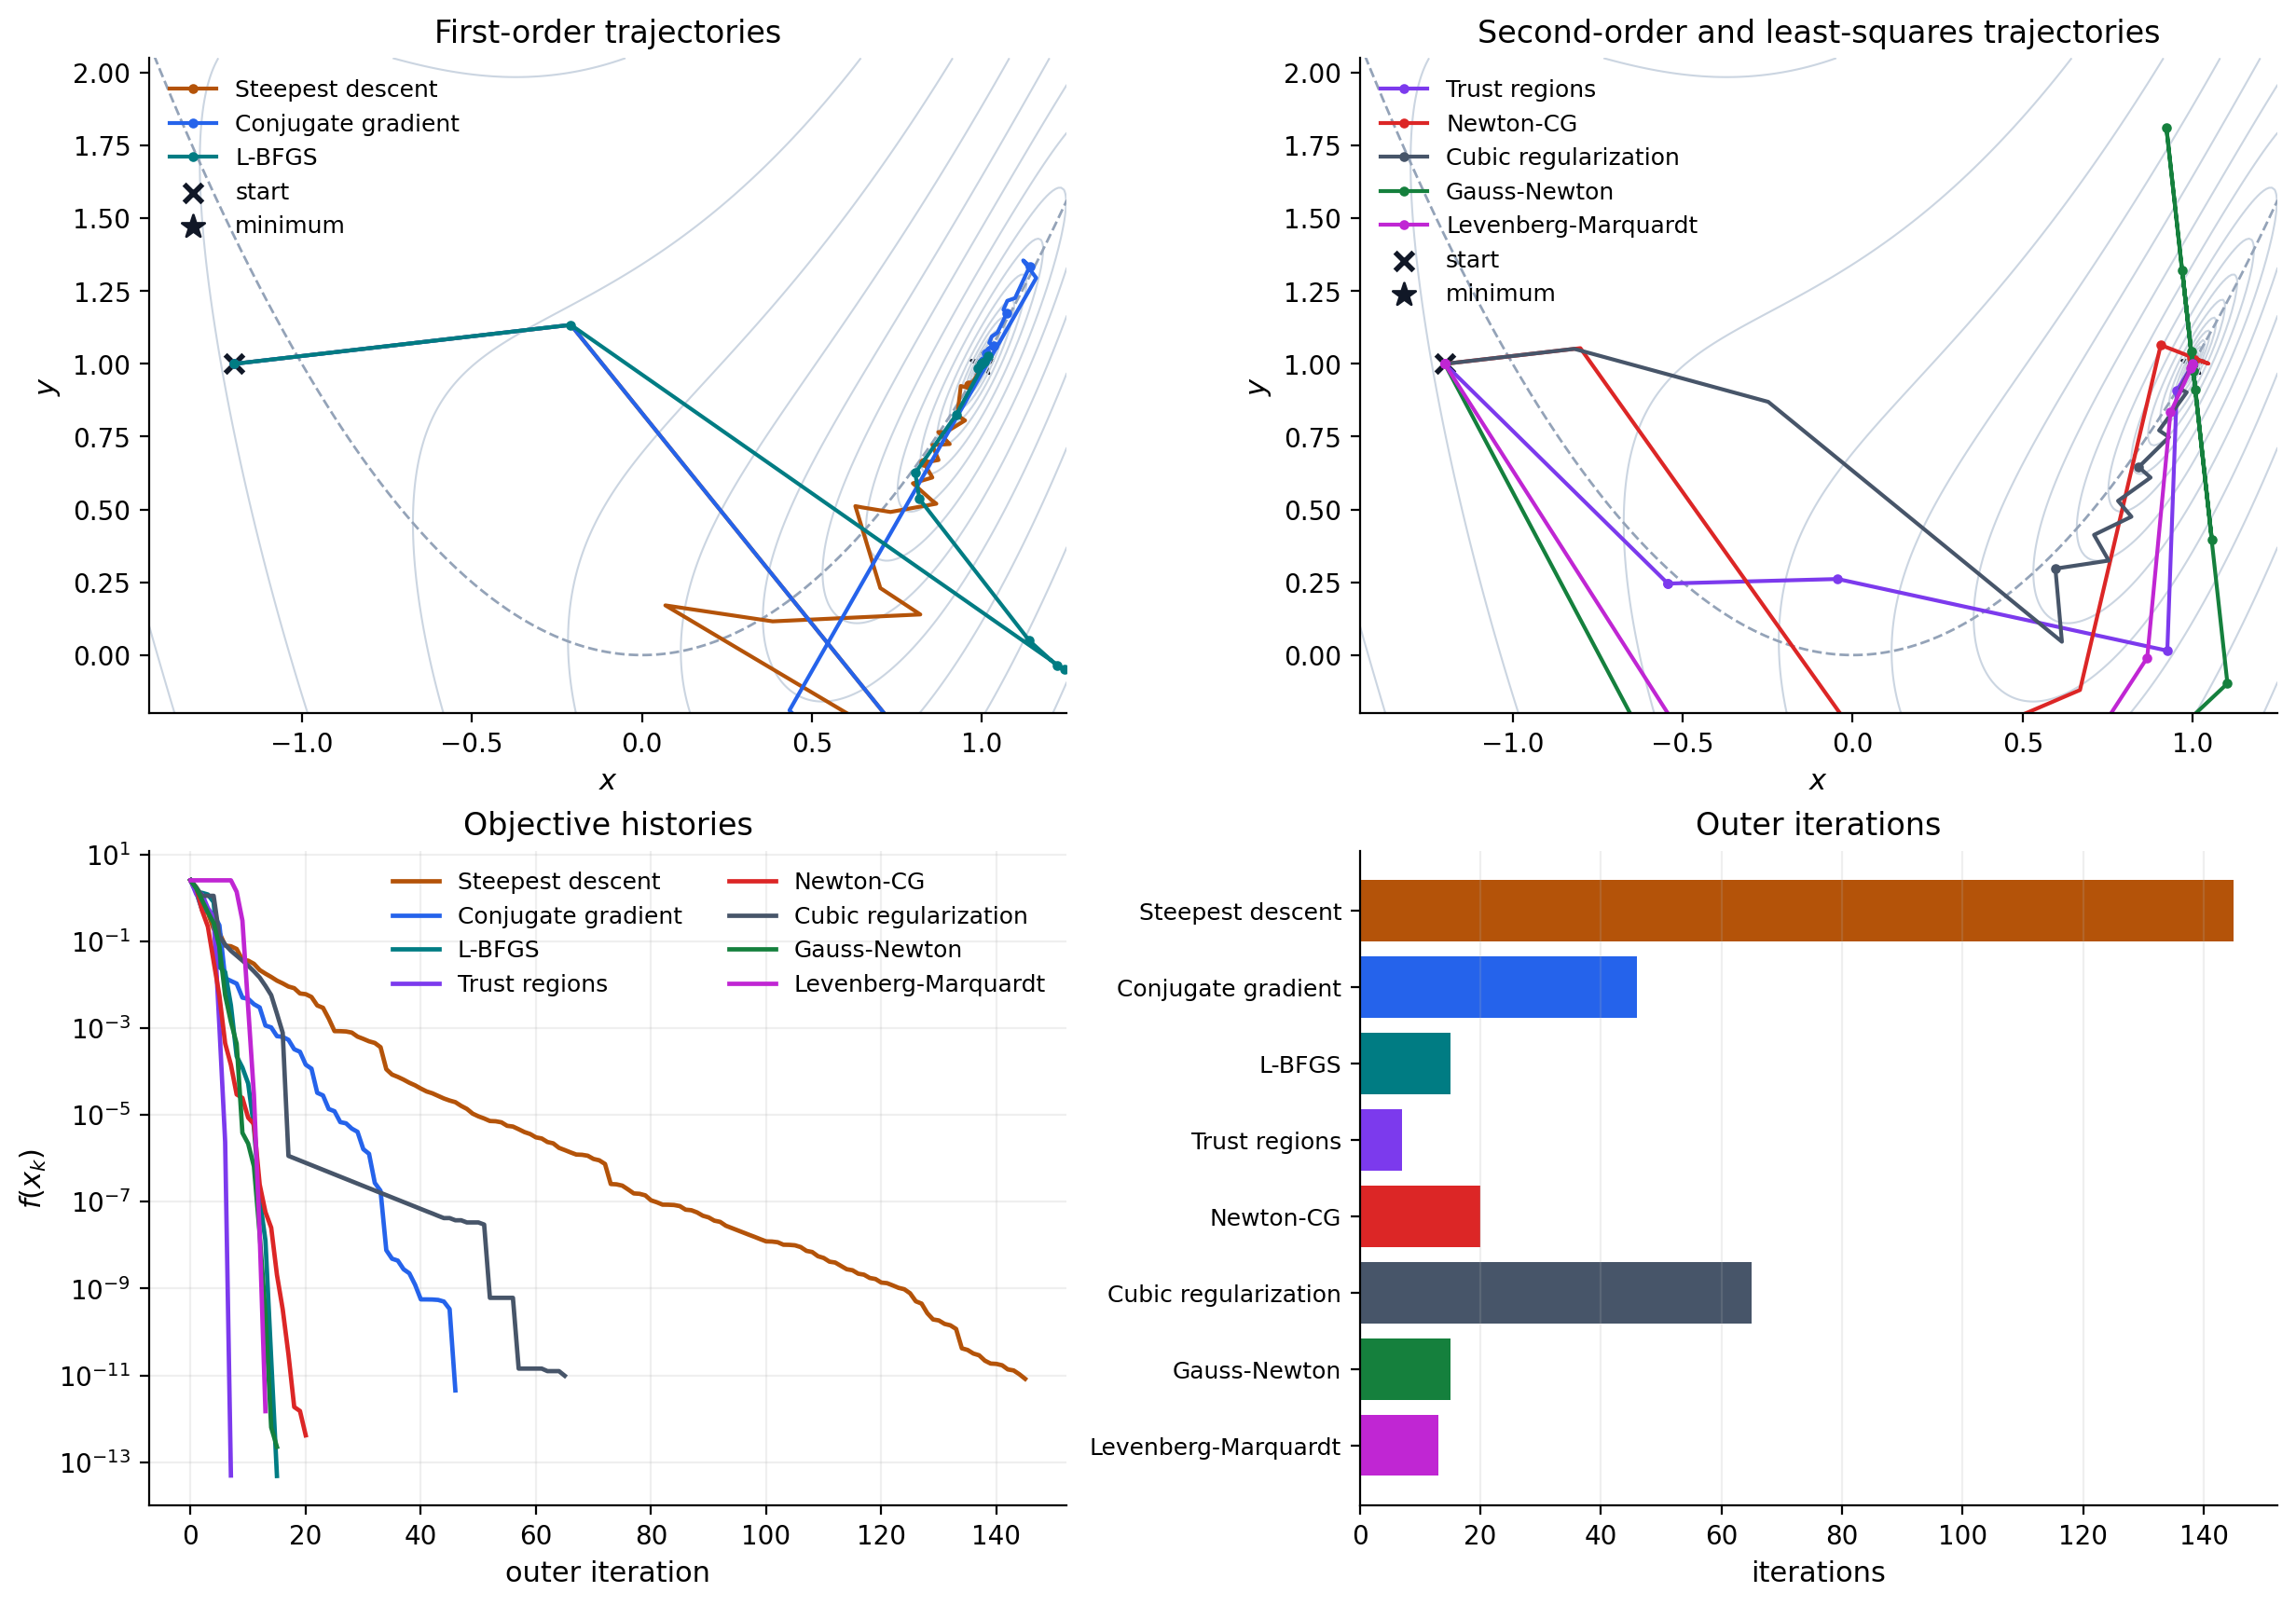

In [3]:
x_grid = np.linspace(-1.45, 1.25, 320)
y_grid = np.linspace(-0.20, 2.05, 320)
xx, yy = np.meshgrid(x_grid, y_grid)
landscape = 0.5 * ((yy - xx**2) ** 2 + (1.0 - xx) ** 2)
levels = np.geomspace(1e-4, 5.0, 18)

colors = {
    "Steepest descent": "#B45309",
    "Conjugate gradient": "#2563EB",
    "L-BFGS": "#007C83",
    "Trust regions": "#7C3AED",
    "Newton-CG": "#DC2626",
    "Cubic regularization": "#475569",
    "Gauss-Newton": "#15803D",
    "Levenberg-Marquardt": "#C026D3",
}

fig, axes = plt.subplots(2, 2, figsize=(12.2, 8.5), constrained_layout=True)


def trajectory_panel(ax, families, title):
    ax.contour(xx, yy, landscape, levels=levels, colors="#CBD5E1", linewidths=0.75)
    ax.plot(x_grid, x_grid**2, color="#94A3B8", linestyle="--", linewidth=1.0)
    for result in results:
        if result["family"] not in families:
            continue
        path = result["path"]
        ax.plot(
            path[:, 0],
            path[:, 1],
            marker="o",
            markevery=max(1, len(path) // 10),
            markersize=2.8,
            linewidth=1.5,
            color=colors[result["name"]],
            label=result["name"],
        )
    ax.scatter(*x0, color="#111827", marker="x", s=50, linewidths=2, label="start")
    ax.scatter(1.0, 1.0, color="#111827", marker="*", s=85, label="minimum")
    ax.set(xlim=(x_grid[0], x_grid[-1]), ylim=(y_grid[0], y_grid[-1]))
    ax.set(title=title, xlabel="$x$", ylabel="$y$")
    ax.legend(frameon=False, fontsize=9, loc="upper left")


trajectory_panel(axes[0, 0], {"first"}, "First-order trajectories")
trajectory_panel(
    axes[0, 1],
    {"second", "least-squares"},
    "Second-order and least-squares trajectories",
)

for result in results:
    values = np.maximum([row.cost for row in result["history"]], 1e-16)
    axes[1, 0].semilogy(
        np.arange(len(values)),
        values,
        linewidth=1.7,
        color=colors[result["name"]],
        label=result["name"],
    )
axes[1, 0].set(title="Objective histories", xlabel="outer iteration", ylabel="$f(x_k)$")
axes[1, 0].grid(alpha=0.2)
axes[1, 0].legend(frameon=False, fontsize=9, ncol=2)

names = [result["name"] for result in results]
iterations = [result["history"][-1].iter for result in results]
axes[1, 1].barh(
    np.arange(len(names)),
    iterations,
    color=[colors[name] for name in names],
)
axes[1, 1].set_yticks(np.arange(len(names)), labels=names, fontsize=9)
axes[1, 1].invert_yaxis()
axes[1, 1].set(title="Outer iterations", xlabel="iterations")
axes[1, 1].grid(axis="x", alpha=0.2)

plt.show()

The comparison suggests a practical progression. Start with conjugate gradient
or L-BFGS for a generic smooth model. Move to Newton-CG, trust regions, or cubic
regularization when accurate Hessian products justify their cost. When the
model is genuinely a sum of squared residuals, preserve that structure with
`LeastSquares`; Gauss--Newton and Levenberg--Marquardt can then operate on
$J_x^*J_x$ without forming either the Jacobian or the full Hessian.